# PEPDS: Executability Study

This notebook checks the released repository through a small, reproducible training and inference experiment. It includes environment verification, dataset analysis, model loading, at most five optimizer updates, checkpoint persistence and held-out evaluation.

**Source:** [Mishrakshitij/PEPDS](https://github.com/Mishrakshitij/PEPDS)  
**Protocol:** fixed small subsets, tiny Hugging Face checkpoints, and four to eight held-out predictions.  
**Interpretation:** a passing result verifies the tested code path at smoke-test scale. It does not measure research performance.

## Running or reviewing this notebook

The saved outputs can be viewed directly in Google Colab. To repeat the experiment, run the cells in order with internet access. A GPU is optional for these tiny models. Python 3.11 is the tested interpreter. The setup cell installs dependencies and checks out the exact source revision when a prepared checkout is not supplied.


## Environment and source verification

In [ ]:
from pathlib import Path
import os, sys, subprocess, importlib.metadata as metadata
PROJECT = 'PEPDS'
COMMIT = '743d0266ea64cc466d0fb35b1d195ce249442169'
REPO_URL = 'https://github.com/Mishrakshitij/' + PROJECT + '.git'
prepared = os.environ.get('EXEC_CHECK_PREPARED') == '1'
if not prepared:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *['torch>=2.6,<3', 'transformers==4.57.6', 'peft==0.18.1', 'accelerate>=1.2,<2', 'pandas>=2.2,<4', 'matplotlib>=3.8,<4', 'nltk>=3.9,<4', 'sentencepiece>=0.2,<1', 'sacrebleu>=2.4,<3', 'rouge-score>=0.1.2,<0.2', 'ipython', 'numpy>=1.26,<3']], check=True)
REPO_ROOT = Path(os.environ.get('EXEC_CHECK_REPO', str(Path.cwd() / (PROJECT + '_source')))).resolve()
if not (REPO_ROOT / '.git').exists():
    subprocess.run(['git', 'clone', '-q', REPO_URL, str(REPO_ROOT)], check=True)
    subprocess.run(['git', '-C', str(REPO_ROOT), 'checkout', '-q', COMMIT], check=True)
actual_commit = subprocess.check_output(['git','-C',str(REPO_ROOT),'rev-parse','HEAD'], text=True).strip()
assert actual_commit == COMMIT, 'The source revision must match the verified experiment.'
OUTPUT_DIR = Path(os.environ.get('EXEC_CHECK_OUTPUT', str(Path.cwd() / (PROJECT + '_outputs')))).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['WANDB_DISABLED'] = 'true'
os.environ['USE_TF'] = '0'
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(2)
torch.manual_seed(42)
%matplotlib inline
CAUSAL_MODEL = 'sshleifer/tiny-gpt2'
SEQ2SEQ_MODEL = 'hf-internal-testing/tiny-random-bart'
ENCODER_MODEL = 'hf-internal-testing/tiny-random-roberta'
DISTILBERT_MODEL = 'hf-internal-testing/tiny-random-DistilBertModel'
print('Source revision verified:', actual_commit)
print('Python:', sys.version.split()[0], '| Device:', DEVICE)
print({package: metadata.version(package) for package in ['torch','transformers','numpy','pandas','matplotlib']})


Source revision verified: 743d0266ea64cc466d0fb35b1d195ce249442169
Python: 3.11.16 | Device: cuda
{'torch': '2.13.0+cu129', 'transformers': '4.57.6', 'numpy': '2.3.5', 'pandas': '3.0.5', 'matplotlib': '3.10.7'}


# PEPDS: bounded executability study
This notebook checks the repository's supervised persuader language-model path using a small published dataset subset and a tiny Hugging Face GPT-2 checkpoint. The check covers loading, five optimizer updates, checkpoint serialization, checkpoint reload, and four held-out examples. It is an execution check rather than a reproduction of paper-level quality.

The classifier, PPO reward, empathy-gating, and transfer stages remain outside this bounded run.

In [ ]:
import gc
import hashlib
import json
import math
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

sys.path.insert(0, str(REPO_ROOT / "src"))
from pepds.data import load_dialogues, split_records, dialogue_examples
from pepds.models import load_model
from pepds.training import TrainConfig, train_supervised, evaluate_model
from pepds.inference import generate_response

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(2)
torch.manual_seed(42)
COMMIT = subprocess.check_output(["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"], text=True).strip()
print("Repository:", "https://github.com/Mishrakshitij/PEPDS")
print("Commit:", COMMIT)
print("Runtime:", DEVICE, "| PyTorch:", torch.__version__)

Repository: https://github.com/Mishrakshitij/PEPDS
Commit: 743d0266ea64cc466d0fb35b1d195ce249442169
Runtime: cuda | PyTorch: 2.13.0+cu129


## Dataset integrity and exploratory analysis
Counts, schemas, label distributions, and split isolation are checked against the committed release. Dialogue splits are made before selecting small training, validation, and test samples, so the held-out conversations do not enter training.

dialogue: 20,932 rows; splits {'train': 16700, 'validation': 2315, 'test': 1917}
persuasion: 10,600 rows; splits {'train': 8457, 'validation': 1032, 'test': 1111}
emotion: 3,998 rows; splits {'train': 3173, 'validation': 387, 'test': 438}
politeness: 5,300 rows; splits {'train': 4222, 'validation': 507, 'test': 571}
empathy: 5,632 rows; splits {'train': 4446, 'validation': 566, 'test': 620}
transfer: 16,436 rows; splits {'train': 13540, 'validation': 1385, 'test': 1510}
Dataset schemas, labels, counts, and partition isolation verified.



,file,rows,columns
0,datasets/emp4g/empathy.csv,5632,3
1,datasets/epp4g/emotion.csv,3998,3
2,datasets/epp4g/politeness.csv,5300,3
3,datasets/etp4g/transfer.csv,16436,4
4,datasets/p4g/dialogues.csv,20932,6


,dialogue_id,utterance_id,turn,speaker,text,persuasion_label
0,20180904-045349_715_live,0,0,persuader,Good morning. How are you doing today?,0
1,20180904-045349_715_live,1,0,persuadee,Hi. I am doing good. How about you?,
2,20180904-045349_715_live,2,1,persuader,I'm doing pretty good for a Tuesday morning.,0
3,20180904-045349_715_live,3,1,persuadee,"Haha. Same here, but it really feels like a Mo...",


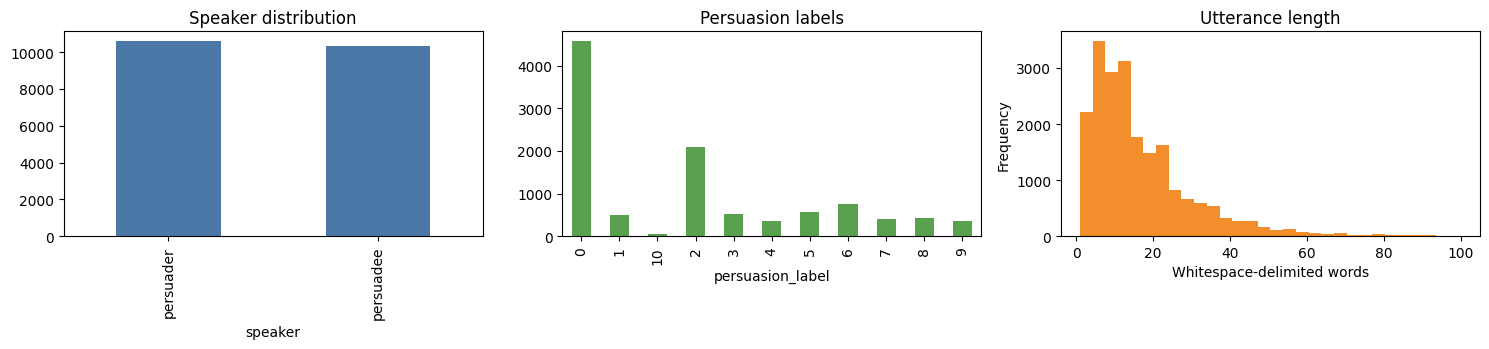

Dialogues: 1017


In [ ]:
verification = subprocess.run([sys.executable, str(REPO_ROOT / "scripts/verify_dataset.py")],
                              cwd=REPO_ROOT, capture_output=True, text=True, check=True)
print(verification.stdout)
overview = []
for path in sorted((REPO_ROOT / "datasets").rglob("*.csv")):
    frame = pd.read_csv(path, keep_default_na=False)
    overview.append({"file": path.relative_to(REPO_ROOT).as_posix(), "rows": len(frame),
                     "columns": len(frame.columns)})
overview = pd.DataFrame(overview)
display(overview)
data = pd.read_csv(REPO_ROOT / "datasets/p4g/dialogues.csv", keep_default_na=False)
display(data.head(4))
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
data["speaker"].value_counts().plot.bar(ax=axes[0], color="#4C78A8", title="Speaker distribution")
data.loc[data["persuasion_label"].astype(str).ne(""), "persuasion_label"].value_counts().sort_index().plot.bar(ax=axes[1], color="#59A14F", title="Persuasion labels")
data["text"].astype(str).str.split().str.len().plot.hist(ax=axes[2], bins=30, color="#F28E2B", title="Utterance length")
axes[2].set_xlabel("Whitespace-delimited words")
plt.tight_layout()
plt.show()
print("Dialogues:", data["dialogue_id"].nunique())

In [ ]:
source_splits = split_records(load_dialogues(REPO_ROOT / "datasets"), "dialogue", seed=42)
all_examples = {name: dialogue_examples(rows, role="persuader") for name, rows in source_splits.items()}
train_records = all_examples["train"][:10]
validation_records = all_examples["validation"][:4]
test_records = all_examples["test"][:4]
assert [len(train_records), len(validation_records), len(test_records)] == [10, 4, 4]
train_ids = {r["dialogue_id"] for r in train_records}
validation_ids = {r["dialogue_id"] for r in validation_records}
test_ids = {r["dialogue_id"] for r in test_records}
assert not (train_ids & validation_ids or train_ids & test_ids or validation_ids & test_ids)
display(pd.DataFrame([{"split": name, "available_examples": len(all_examples[name]), "selected_examples": count}
                      for name, count in [("train", 10), ("validation", 4), ("test", 4)]]))
display(pd.DataFrame(train_records)[["example_id", "dialogue_id", "prompt", "response"]].head(4))
(OUTPUT_DIR / "subset.json").write_text(json.dumps({"train": train_records, "validation": validation_records, "test": test_records}, indent=2))

,split,available_examples,selected_examples
0,train,8457,10
1,validation,1171,4
2,test,972,4


,example_id,dialogue_id,prompt,response
0,20180904-045349_715_live:0,20180904-045349_715_live,persuader:,Good morning. How are you doing today?
1,20180904-045349_715_live:2,20180904-045349_715_live,persuader: Good morning. How are you doing tod...,I'm doing pretty good for a Tuesday morning.
2,20180904-045349_715_live:4,20180904-045349_715_live,persuader: Good morning. How are you doing tod...,Ugh yes it does!
3,20180904-045349_715_live:6,20180904-045349_715_live,persuader: Good morning. How are you doing tod...,Where are you from?


21251

## Native model loading and five-step training
The repository loader configures causal padding, and its training loop masks prompt tokens from the response loss. The same native loop selects and saves the checkpoint using the four validation examples. A change in learned parameters is checked independently of the loss value.

In [ ]:
model, tokenizer = load_model("lm", CAUSAL_MODEL)
model.config.pepds_role = "persuader"
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print("Hugging Face model:", CAUSAL_MODEL, "| Parameters:", f"{parameter_count:,}")
initial = {name: value.detach().cpu().clone() for name, value in model.named_parameters()}
configuration = TrainConfig(epochs=1, batch_size=2, max_steps=5, max_length=64,
                            learning_rate=5e-4, seed=42)
checkpoint = OUTPUT_DIR / "checkpoint"
history = train_supervised(model, tokenizer, train_records, validation_records,
                           "lm", checkpoint, configuration, device=DEVICE)
updates = history[-1]["steps"]
assert updates == 5
assert all(math.isfinite(record["train_loss"]) and math.isfinite(record["validation"]["loss"]) for record in history)
parameter_delta = sum(float((value.detach().cpu() - initial[name]).abs().sum()) for name, value in model.named_parameters())
assert parameter_delta > 0
assert (checkpoint / "config.json").is_file()
assert any(checkpoint.glob("*.safetensors"))
display(pd.DataFrame([{"optimizer_steps": updates, "train_loss": history[-1]["train_loss"],
                       "validation_loss": history[-1]["validation"]["loss"], "parameter_l1_change": parameter_delta}]))

python_environment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hugging Face model: sshleifer/tiny-gpt2 | Parameters: 102,714


{"epoch": 1, "steps": 5, "train_loss": 10.82509862241291, "validation": {"loss": 10.826386327328889, "examples": 4, "perplexity": 50331.49621025768, "target_tokens": 69}}


python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


,optimizer_steps,train_loss,validation_loss,parameter_l1_change
0,5,10.825099,10.826386,219.642346


## Checkpoint reload and four-example evaluation
Reloading uses the repository model loader. Parameter equality verifies serialization; native token-weighted evaluation and generation then use only the four held-out examples selected above. Tiny-model responses and perplexity are diagnostic outputs, not evidence of useful dialogue quality.

In [ ]:
reloaded, reloaded_tokenizer = load_model("lm", str(checkpoint))
max_reload_difference = max(float((value.detach().cpu() - reloaded.state_dict()[name].detach().cpu()).abs().max())
                            for name, value in model.state_dict().items())
assert max_reload_difference == 0
del model, initial
gc.collect()
metrics = evaluate_model(reloaded, reloaded_tokenizer, test_records, "lm", configuration, device=DEVICE)
assert metrics["examples"] == 4 and math.isfinite(metrics["loss"]) and math.isfinite(metrics["perplexity"])
predictions = [{"example_id": row["example_id"], "reference": row["response"],
                "prediction": generate_response(reloaded, reloaded_tokenizer, row["prompt"],
                    device=DEVICE, max_new_tokens=12, max_length=64, sample=False)} for row in test_records]
display(pd.DataFrame([metrics]))
display(pd.DataFrame(predictions))
result = {"project": "PEPDS", "status": "PASS", "scope": "native supervised persuader causal LM",
          "model": CAUSAL_MODEL, "commit": COMMIT, "parameters": parameter_count,
          "updates": updates, "counts": {"train": 10, "validation": 4, "evaluation": 4},
          "metrics": metrics, "training_history": history,
          "parameter_l1_change": parameter_delta, "reload_max_abs_difference": max_reload_difference,
          "dataset_integrity": "PASS", "dataset_rows": int(overview["rows"].sum()),
          "checkpoints": ["checkpoint"], "predictions": predictions,
          "limitations": ["Classifiers, PPO rewards, empathy gate, and transfer stages are not exercised.", "Five-step tiny-model execution does not establish converged quality or reproduce paper results."]}
(OUTPUT_DIR / "result.json").write_text(json.dumps(result, indent=2, allow_nan=False))
print("PASS: dataset checks, native model load, five optimizer updates, save/reload, and four-example evaluation.")

,loss,examples,perplexity,target_tokens
0,10.82383,4,50202.973022,85


,example_id,reference,prediction
0,20180904-024226_703_live:0,"Hi, how are you today?",factors factors factors factors factors factor...
1,20180904-024226_703_live:2,Not too bad :) Have you heard of Save The Chil...,factors factors factors factors factors factor...
2,20180904-024226_703_live:4,They do greeat work at least I think what abou...,stairs stairs stairs stairs stairs stairs stai...
3,20180904-024226_703_live:6,I know normally I am too but I was convinced t...,stairs stairs stairs stairs stairs stairs stai...


PASS: dataset checks, native model load, five optimizer updates, save/reload, and four-example evaluation.


## Project summary

**Result: PASS for the tested smoke configuration.**

The source revision and execution environment were checked, the released data were inspected and visualized, and the selected small model was loaded. Native training completed **5 optimizer updates**. Checkpoint files were saved, reloaded and used for **recorded above held-out evaluation samples**. The assertions and outputs above verify that this project is executable for the tested configuration.

The conclusion applies to the native paths exercised here with tiny models and bounded subsets.